## Visualización de los clusters

Las transacciones tienen 32 variables, así que no se pueden dibujar directamente. Se usa PCA para proyectarlas a 2 dimensiones: busca el plano donde los datos quedan más separados y aplasta el resto. Es como fotografiar un objeto 3D desde el ángulo en el que mejor se distingue su forma; se pierde información, pero se ve la estructura.

C:\Users\jacobo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.3.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


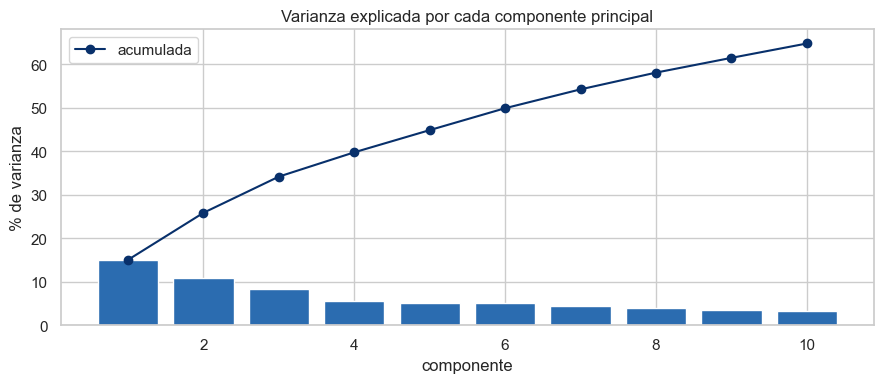

Las 2 primeras componentes explican el 25.8 % de la varianza


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

AZUL = "#2b6cb0"
COLORES = ["#9ecae1", "#2b6cb0", "#08306b"]
sns.set_theme(style="whitegrid")

X_train = pd.read_parquet("datos_ml/X_train.parquet")
modelo = joblib.load("modelos/kmeans.joblib")
scores = pd.read_parquet("modelos/kmeans_scores_train.parquet")
cluster = scores["cluster"].values
distancia = scores["distancia"].values

pca = PCA(n_components=10, random_state=42).fit(X_train)
var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), var, color=AZUL)
ax.plot(range(1, 11), np.cumsum(var), color="#08306b", marker="o", label="acumulada")
ax.set_title("Varianza explicada por cada componente principal")
ax.set_xlabel("componente")
ax.set_ylabel("% de varianza")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Las 2 primeras componentes explican el {var[:2].sum():.1f} % de la varianza")

C:\Users\jacobo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


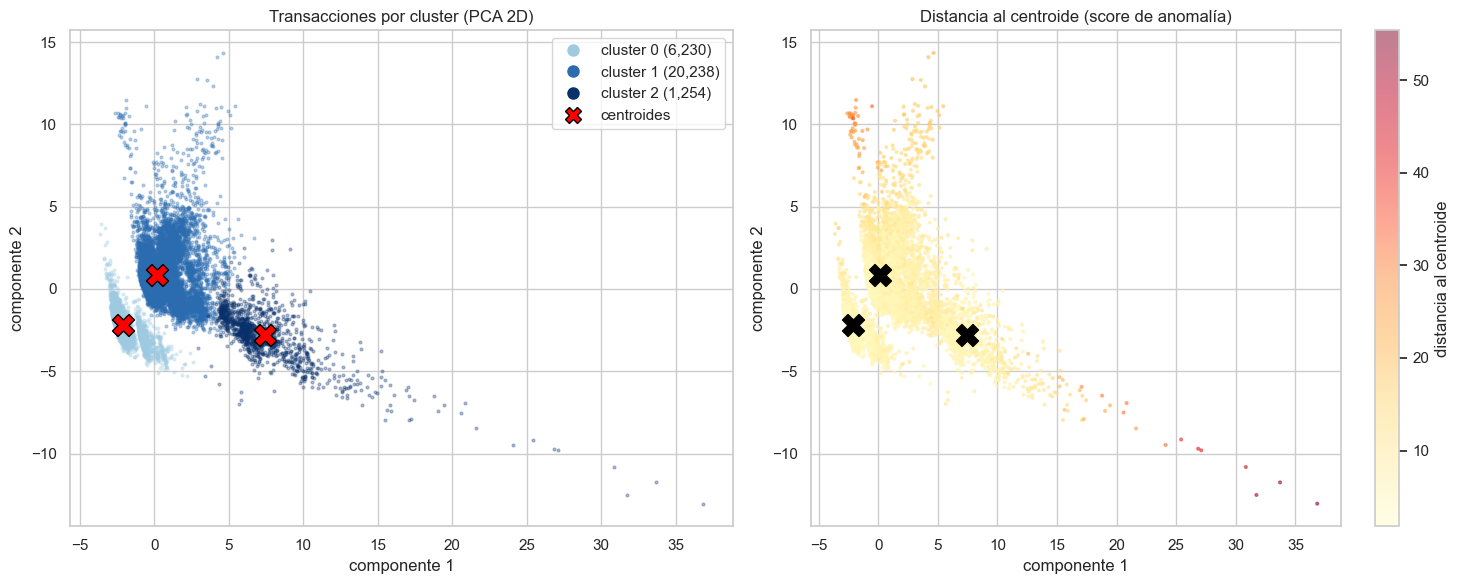

In [2]:
proyeccion = PCA(n_components=2, random_state=42).fit(X_train)
P = proyeccion.transform(X_train)
cen = proyeccion.transform(modelo.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for c in range(3):
    m = cluster == c
    axes[0].scatter(P[m, 0], P[m, 1], s=4, alpha=0.3, color=COLORES[c])
axes[0].scatter(cen[:, 0], cen[:, 1], marker="X", s=250, color="red", edgecolor="black", zorder=5)
axes[0].set_title("Transacciones por cluster (PCA 2D)")
axes[0].set_xlabel("componente 1")
axes[0].set_ylabel("componente 2")
# leyenda aparte: los puntos reales son diminutos y no se verían
handles = [Line2D([], [], marker="o", linestyle="", color=COLORES[c], markersize=8,
                  label=f"cluster {c} ({(cluster == c).sum():,})") for c in range(3)]
handles.append(Line2D([], [], marker="X", linestyle="", color="red", markeredgecolor="black",
                      markersize=12, label="centroides"))
axes[0].legend(handles=handles)

s = axes[1].scatter(P[:, 0], P[:, 1], c=distancia, s=4, alpha=0.5, cmap="YlOrRd")
axes[1].scatter(cen[:, 0], cen[:, 1], marker="X", s=250, color="black", zorder=5)
plt.colorbar(s, ax=axes[1], label="distancia al centroide")
axes[1].set_title("Distancia al centroide (score de anomalía)")
axes[1].set_xlabel("componente 1")
axes[1].set_ylabel("componente 2")

plt.tight_layout()
plt.show()

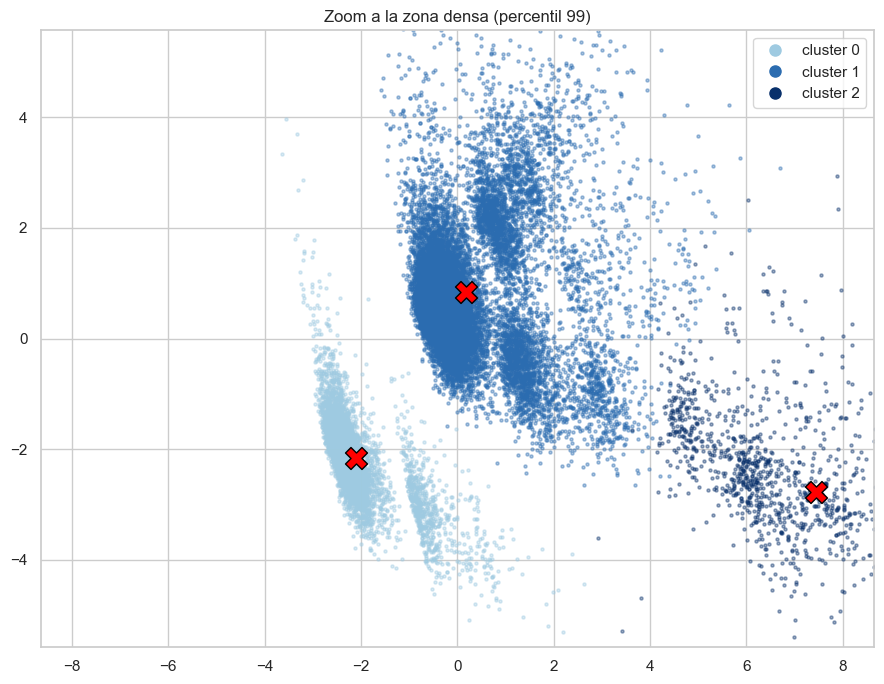

In [3]:
lim = np.percentile(np.abs(P), 99, axis=0)

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(3):
    m = cluster == c
    ax.scatter(P[m, 0], P[m, 1], s=5, alpha=0.4, color=COLORES[c])
ax.scatter(cen[:, 0], cen[:, 1], marker="X", s=250, color="red", edgecolor="black", zorder=5)
ax.set_xlim(-lim[0], lim[0])
ax.set_ylim(-lim[1], lim[1])
ax.set_title("Zoom a la zona densa (percentil 99)")
ax.legend(handles=[Line2D([], [], marker="o", linestyle="", color=COLORES[c], markersize=8,
                          label=f"cluster {c}") for c in range(3)])
plt.tight_layout()
plt.show()

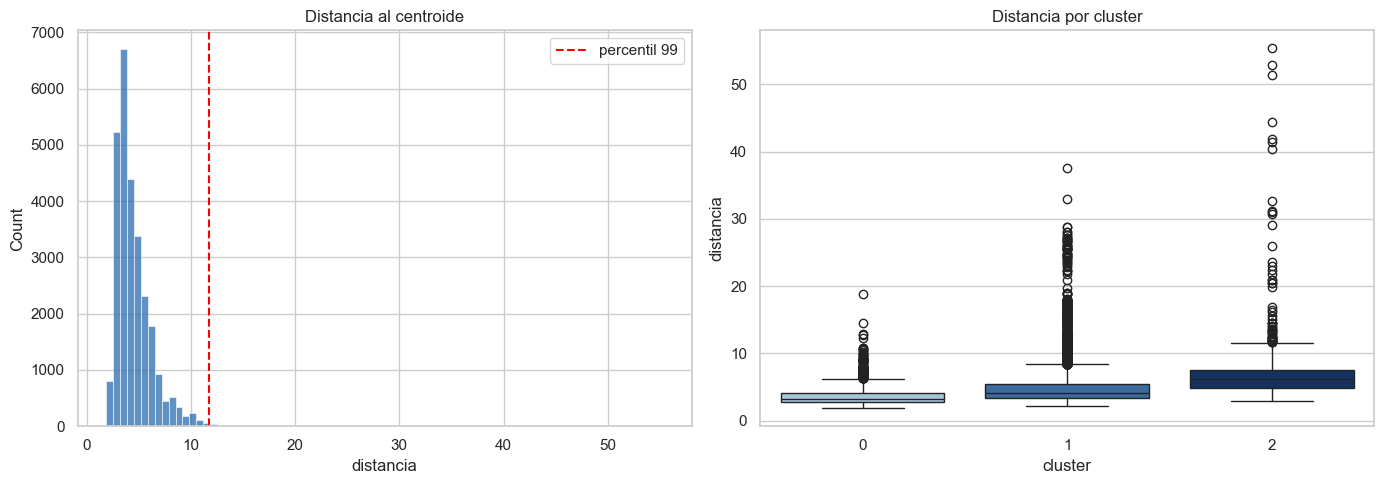

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(distancia, bins=80, color=AZUL, ax=axes[0])
axes[0].axvline(np.percentile(distancia, 99), color="red", linestyle="--", label="percentil 99")
axes[0].set_title("Distancia al centroide")
axes[0].set_xlabel("distancia")
axes[0].legend()

sns.boxplot(x=cluster, y=distancia, hue=cluster, palette=COLORES, legend=False, ax=axes[1])
axes[1].set_title("Distancia por cluster")
axes[1].set_xlabel("cluster")
axes[1].set_ylabel("distancia")

plt.tight_layout()
plt.show()

vale, ahora quiero obtener alguna metrica como accuracy o algo asi para evaluar y comparar con mis compañeros los resultados y ya decidir que modelo usar para el proyecto